# Scowtt ML Engineer Take-Home Assessment

### Process Documentation

For Data cleaning, I focused mainly three areas.:
- I used customer_unique_id for aggregation because appox. 3345 customers had multiple IDs for orders
- I kept the cancelled/unavailable orders as behavorial sigals
- I kept the NaN values because XGBosst can handle it natively



Feature Engineering, I focused on RFM analyis as these values are proven predictors of repeat purchase. Beyond that, I added delivery experiences, payment behavior, failure rate and review scores. All the features were computed from pre-cutoff window in order to prevent data leakage.

Temporal Design, I choose a cutoff date of June 1 because the data volume dropped sharply after August 2028. And I chose a 60-day label window instead of 30 days becausse the dataset has 97% one-time buyers. a 30-day winodow only had ~150 positives while a 60 day winodow had 318 postivies. 


Model Design:
For the ML model, I choose XGBoost over neural networks because it handles the  non-linear relationships, handles missing values automatically, and requires minimal feature preprocessing compared to neural networks. This choice is consistent with Grinsztajn et al. (NeurIPS 2022) showing tree-based models outperform deep learning on tabular data. 


## 1. Download Data

In [1]:
!git clone https://github.com/Scowtt-Inc/scowtt-shared.git /kaggle/working/scowtt-shared
!unzip -o /kaggle/working/scowtt-shared/data/datasets.zip -d /kaggle/working/

Cloning into '/kaggle/working/scowtt-shared'...
remote: Enumerating objects: 7, done.
remote: Total 7 (delta 0), reused 0 (delta 0), pack-reused 7 (from 2)
Receiving objects: 100% (7/7), 42.60 MiB | 42.11 MiB/s, done.
Archive:  /kaggle/working/scowtt-shared/data/datasets.zip
   creating: /kaggle/working/datasets/
  inflating: /kaggle/working/__MACOSX/._datasets  
  inflating: /kaggle/working/datasets/olist_sellers_dataset.csv  
  inflating: /kaggle/working/__MACOSX/datasets/._olist_sellers_dataset.csv  
  inflating: /kaggle/working/datasets/olist_marketing_qualified_leads_dataset.csv  
  inflating: /kaggle/working/__MACOSX/datasets/._olist_marketing_qualified_leads_dataset.csv  
  inflating: /kaggle/working/datasets/product_category_name_translation.csv  
  inflating: /kaggle/working/__MACOSX/datasets/._product_category_name_translation.csv  
  inflating: /kaggle/working/datasets/olist_orders_dataset.csv  
  inflating: /kaggle/working/__MACOSX/datasets/._olist_orders_dataset.csv  
  in

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (roc_auc_score, roc_curve, classification_report,
                             f1_score, r2_score, mean_squared_error)
from lightgbm import LGBMClassifier
import warnings
import time
warnings.filterwarnings('ignore')
np.random.seed(42)

data_path = '/kaggle/working/datasets/'

customers = pd.read_csv(data_path + 'olist_customers_dataset.csv')
items = pd.read_csv(data_path + 'olist_order_items_dataset.csv')
orders = pd.read_csv(data_path + 'olist_orders_dataset.csv')
products = pd.read_csv(data_path + 'olist_products_dataset.csv')
payments = pd.read_csv(data_path + 'olist_order_payments_dataset.csv')
translations = pd.read_csv(data_path + 'product_category_name_translation.csv')
reviews = pd.read_csv(data_path + 'olist_order_reviews_dataset.csv')

for col in ['order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date',
            'order_delivered_customer_date', 'order_estimated_delivery_date']:
    orders[col] = pd.to_datetime(orders[col])


## 2. Data Exploration

In [3]:
print(f'customer_id: {customers["customer_id"].nunique()}')
print(f'customer_unique_id: {customers["customer_unique_id"].nunique()}')
print(f'Repeat Buyers {customers["customer_id"].nunique() - customers["customer_unique_id"].nunique()}\n')

customer_id: 99441
customer_unique_id: 96096
Repeat Buyers 3345



In [4]:
print(f'{orders["order_purchase_timestamp"].min().date()} to {orders["order_purchase_timestamp"].max().date()}')
print(orders['order_status'].value_counts())
print(orders.isnull().sum()[orders.isnull().sum() > 0])

2016-09-04 to 2018-10-17
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
dtype: int64


In [5]:
print(payments['payment_type'].value_counts())

payment_type
credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
not_defined        3
Name: count, dtype: int64


## 3. Data Aggregation

In [6]:
print(f'Customers: {customers.shape[0]:,} rows, {customers["customer_unique_id"].nunique():} unique')

Customers: 99,441 rows, 96096 unique


In [7]:
lead_to_purchase = customers.merge(orders, on='customer_id', how='left')
print(f'{lead_to_purchase.shape[0]:,} rows')
print(f'  Orders matched: {lead_to_purchase["order_id"].notna().sum():,}')

99,441 rows
  Orders matched: 99,441


In [8]:
products = products.merge(translations, on='product_category_name', how='left')
items_enriched = items.merge(
    products[['product_id', 'product_category_name_english', 'product_weight_g']],
    on='product_id', how='left'
)
lead_browse_purchase = lead_to_purchase.merge(items_enriched, on='order_id', how='left')

In [11]:
payments_agg = payments.groupby('order_id').agg(
    total_payment_value=('payment_value', 'sum'),
    max_installments=('payment_installments', 'max'),
).reset_index()
primary_pay = payments.loc[
    payments.groupby('order_id')['payment_value'].idxmax()
][['order_id', 'payment_type']].rename(columns={'payment_type': 'primary_payment_type'})
payments_agg = payments_agg.merge(primary_pay, on='order_id', how='left')

reviews_agg = reviews.groupby('order_id').agg(
    review_score=('review_score', 'mean')
).reset_index()

master = lead_browse_purchase.merge(payments_agg, on='order_id', how='left') \
    .merge(reviews_agg, on='order_id', how='left')

master['order_success'] = master['order_status'].isin(
    ['delivered', 'shipped', 'invoiced', 'processing', 'approved']).astype(int)

print(f'Shape: {master.shape[0]:,} rows × {master.shape[1]} columns')
print(f'Unique customers: {master["customer_unique_id"].nunique():,}')
print(f'Unique orders: {master["order_id"].nunique():,}')
print(f'Date range: {master["order_purchase_timestamp"].min().date()} to {master["order_purchase_timestamp"].max().date()}')
print(f'Successful: {master["order_success"].sum():,} | Failed: {(master["order_success"]==0).sum():,}')

Shape: 113,425 rows × 25 columns
Unique customers: 96,096
Unique orders: 99,441
Date range: 2016-09-04 to 2018-10-17
Successful: 112,104 | Failed: 1,321



## 4. EDA

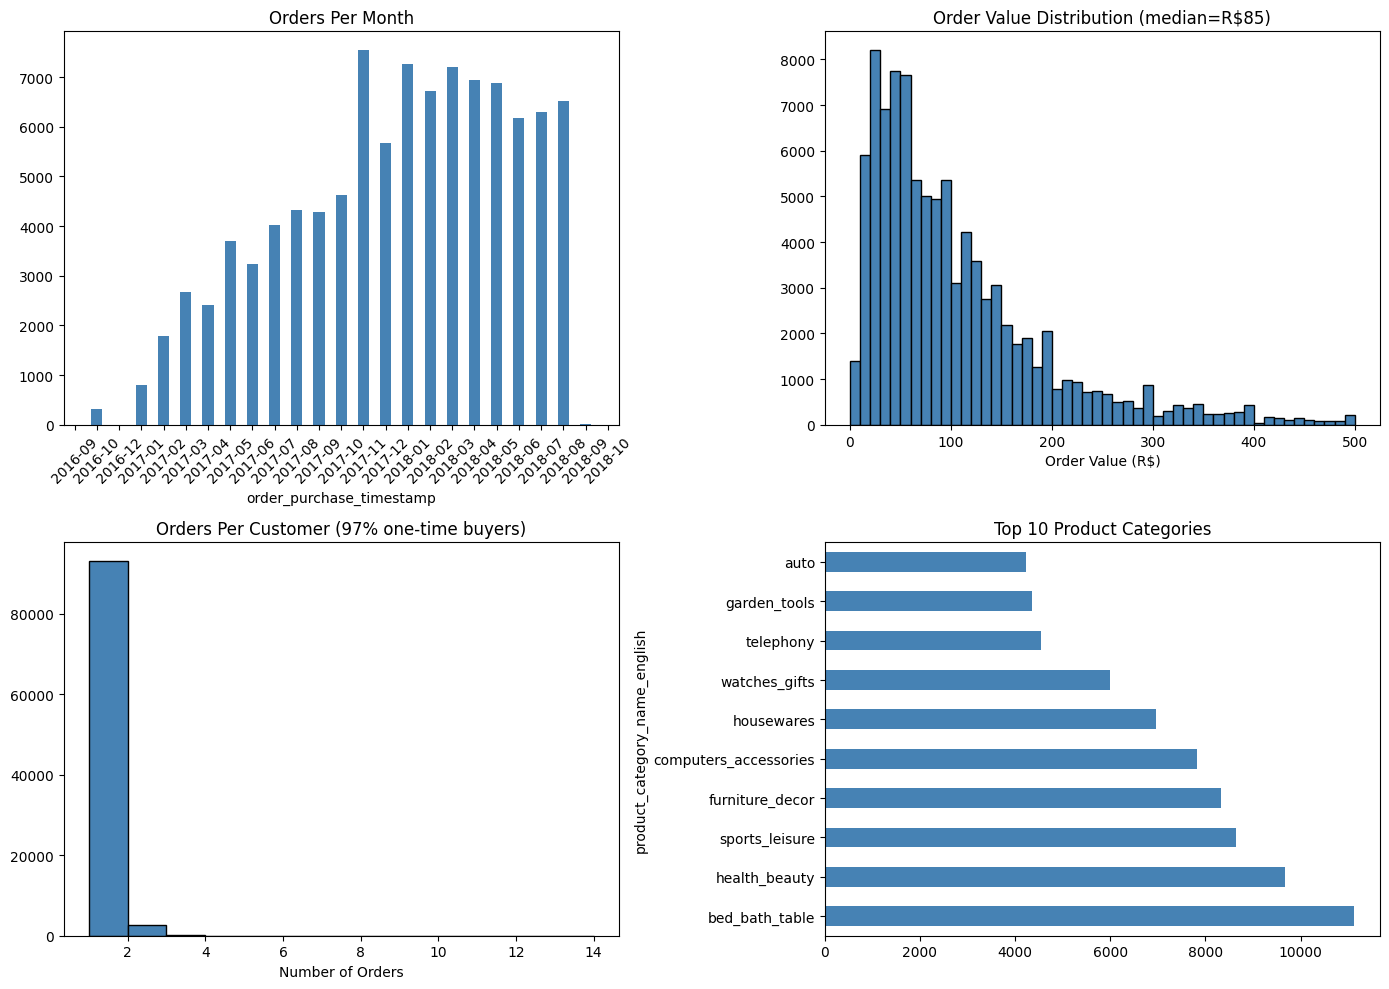

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

monthly = master.groupby(master['order_purchase_timestamp'].dt.to_period('M'))['order_id'].nunique()
monthly.plot(kind='bar', ax=axes[0,0], color='steelblue')
axes[0,0].set_title('Orders Per Month')
axes[0,0].tick_params(axis='x', rotation=45)

ov = master.groupby('order_id')['price'].sum()
axes[0,1].hist(ov[ov < 500], bins=50, edgecolor='black', color='steelblue')
axes[0,1].set_title(f'Order Value Distribution (median=R${ov.median():.0f})')
axes[0,1].set_xlabel('Order Value (R$)')

opc = master.groupby('customer_unique_id')['order_id'].nunique()
pct_onetime = (opc == 1).mean() * 100
axes[1,0].hist(opc, bins=range(1, 15), edgecolor='black', color='steelblue')
axes[1,0].set_title(f'Orders Per Customer ({pct_onetime:.0f}% one-time buyers)')
axes[1,0].set_xlabel('Number of Orders')

master['product_category_name_english'].value_counts().head(10).plot(
    kind='barh', ax=axes[1,1], color='steelblue')
axes[1,1].set_title('Top 10 Product Categories')

plt.tight_layout()
plt.show()

## 5. Temporal Split & Feature Engineering

In [14]:
CUTOFF = pd.Timestamp('2018-06-01')
LABEL_END = pd.Timestamp('2018-08-01')

feature_data = master[master['order_purchase_timestamp'] < CUTOFF]
label_data = master[(master['order_purchase_timestamp'] >= CUTOFF) & 
                    (master['order_purchase_timestamp'] < LABEL_END)]

print(f'Feature window: {feature_data["customer_unique_id"].nunique():,} customers')
print(f'Label window: {label_data["customer_unique_id"].nunique():,} customers ({label_data["order_id"].nunique():,} orders)')

Feature window: 77,808 customers
Label window: 12,332 customers (12,459 orders)


In [16]:

cf = feature_data.groupby('customer_unique_id').agg(
    recency_days=('order_purchase_timestamp', lambda x: (CUTOFF - x.max()).days),
    customer_tenure_days=('order_purchase_timestamp', lambda x: (x.max() - x.min()).days),
    num_orders=('order_id', 'nunique'),
    total_spend=('price', 'sum'),
    avg_order_value=('price', 'mean'),
    max_order_value=('price', 'max'),
    total_freight=('freight_value', 'sum'),
    total_items=('product_id', 'count'),
    unique_products=('product_id', 'nunique'),
    unique_categories=('product_category_name_english', 'nunique'),
    avg_product_weight=('product_weight_g', 'mean'),
    avg_payment_value=('total_payment_value', 'mean'),
    avg_installments=('max_installments', 'mean'),
    num_successful=('order_success', 'sum'),
    num_failed=('order_success', lambda x: (x == 0).sum()),
    customer_state=('customer_state', 'first'),
    days_since_first=('order_purchase_timestamp', lambda x: (CUTOFF - x.min()).days),
    credit_card_pct=('primary_payment_type', lambda x: (x == 'credit_card').mean()),
    avg_review_score=('review_score', 'mean'),
    min_review_score=('review_score', 'min'),
    low_reviews=('review_score', lambda x: (x <= 2).sum()),
).reset_index()

cf['failure_rate'] = cf['num_failed'] / cf['num_orders']
cf['items_per_order'] = cf['total_items'] / cf['num_orders']

succ = feature_data[feature_data['order_success'] == 1].copy()
succ['del_days'] = (succ['order_delivered_customer_date'] - succ['order_purchase_timestamp']).dt.days
succ['del_delay'] = (succ['order_delivered_customer_date'] - succ['order_estimated_delivery_date']).dt.days

del_feat = succ.groupby('customer_unique_id').agg(
    avg_delivery_days=('del_days', 'mean'),
    avg_delivery_delay=('del_delay', 'mean'),
    late_deliveries=('del_delay', lambda x: (x > 0).sum()),
).reset_index()

cf = cf.merge(del_feat, on='customer_unique_id', how='left')
print(f'Customer features: {cf.shape} ({cf.shape[1]-1} features per customer)')

Customer features: (77808, 27) (26 features per customer)


In [21]:
lab = label_data[label_data['order_success'] == 1].groupby('customer_unique_id').agg(
    conversion_value=('price', 'sum')
).reset_index()
lab['propensity_label'] = 1

dataset = cf.merge(lab, on='customer_unique_id', how='left')
dataset['propensity_label'] = dataset['propensity_label'].fillna(0).astype(int)
dataset['conversion_value'] = dataset['conversion_value'].fillna(0)

print(f'Dataset: {dataset.shape}')
print(f'Positive: {(dataset["propensity_label"]==1).sum()} ({dataset["propensity_label"].mean()*100:.2f}%)')
print(f'Negative: {(dataset["propensity_label"]==0).sum()}')

Dataset: (77808, 29)
Positive: 318 (0.41%)
Negative: 77490


In [20]:
cf.columns

Index(['customer_unique_id', 'recency_days', 'customer_tenure_days',
       'num_orders', 'total_spend', 'avg_order_value', 'max_order_value',
       'total_freight', 'total_items', 'unique_products', 'unique_categories',
       'avg_product_weight', 'avg_payment_value', 'avg_installments',
       'num_successful', 'num_failed', 'customer_state', 'days_since_first',
       'credit_card_pct', 'avg_review_score', 'min_review_score',
       'low_reviews', 'failure_rate', 'items_per_order', 'avg_delivery_days',
       'avg_delivery_delay', 'late_deliveries'],
      dtype='object')

In [22]:
numeric_cols = dataset.select_dtypes(include=[np.number]).columns
corr = dataset[numeric_cols].corr()['propensity_label'].drop(['propensity_label', 'conversion_value']).sort_values()
print('Top negative correlations:')
print(corr.head(5).to_string())
print('\nTop positive correlations:')
print(corr.tail(5).to_string())

Top negative correlations:
recency_days         -0.020656
days_since_first     -0.014437
avg_order_value      -0.007874
avg_delivery_days    -0.007204
avg_product_weight   -0.006363

Top positive correlations:
unique_products         0.035840
total_items             0.036937
num_successful          0.037040
customer_tenure_days    0.038667
num_orders              0.049355



## 6. Prepare for Modeling

In [23]:
le = LabelEncoder()
dataset['customer_state_enc'] = le.fit_transform(dataset['customer_state'])

feature_cols = [
    'recency_days', 'customer_tenure_days', 'num_orders', 'total_spend',
    'avg_order_value', 'max_order_value', 'total_freight',
    'total_items', 'unique_products', 'unique_categories', 'avg_product_weight',
    'avg_payment_value', 'avg_installments', 'credit_card_pct',
    'num_successful', 'num_failed', 'failure_rate',
    'avg_delivery_days', 'avg_delivery_delay', 'late_deliveries',
    'days_since_first', 'items_per_order', 'customer_state_enc',
    
]

X = dataset[feature_cols]
y_p = dataset['propensity_label']
y_v = dataset['conversion_value']

X_train, X_test, y_train_p, y_test_p, y_train_v, y_test_v = train_test_split(
    X, y_p, y_v, test_size=0.2, random_state=42, stratify=y_p)

X_train_filled = X_train.fillna(0) 
X_test_filled = X_test.fillna(0)

spw = (y_train_p == 0).sum() /(y_train_p == 1).sum()
print(f'Train: {X_train.shape}  Positives: {y_train_p.sum()}')
print(f'Test: {X_test.shape}  Positives: {y_test_p.sum()}')
print(f'scale_pos_weight: {spw:.0f}')

Train: (62246, 23)  Positives: 254
Test: (15562, 23)  Positives: 64
scale_pos_weight: 244


## 7. Model Comparison

In [24]:
models = {
    'Logistic Regression': (LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42), True),
    'Random Forest': (RandomForestClassifier(n_estimators=200, max_depth=4, class_weight='balanced', random_state=42, n_jobs=-1), True),
    'Gradient Boosting': (GradientBoostingClassifier(n_estimators=200, max_depth=3, learning_rate=0.05, random_state=42, subsample=0.8), True),
    'XGBoost': (xgb.XGBClassifier(n_estimators=200, max_depth=3, learning_rate=0.05, scale_pos_weight=spw,
                                   eval_metric='aucpr', random_state=42, min_child_weight=5, subsample=0.8,
                                   colsample_bytree=0.8, reg_alpha=1, reg_lambda=5), False),
    'LightGBM': (LGBMClassifier(n_estimators=200, max_depth=3, learning_rate=0.05, scale_pos_weight=spw,
                                 random_state=42, subsample=0.8, colsample_bytree=0.8, verbose=-1), False),
}

print(f'{"Model":<25} {"Train AUC":>10} {"Test AUC":>10} {"Gap":>8} {"Time":>7}')
print('-' * 65)

model_results = {}
for name, (model, needs_fill) in models.items():
    Xtr = X_train_filled if needs_fill else X_train
    Xte = X_test_filled if needs_fill else X_test
    start = time.time()
    model.fit(Xtr, y_train_p)
    t = time.time() - start
    tr_auc = roc_auc_score(y_train_p, model.predict_proba(Xtr)[:, 1])
    te_auc = roc_auc_score(y_test_p, model.predict_proba(Xte)[:, 1])
    model_results[name] = {'tr': tr_auc, 'te': te_auc, 'model': model, 'fill': needs_fill}
    print(f'{name:<25} {tr_auc:>10.4f} {te_auc:>10.4f} {tr_auc-te_auc:>8.4f} {t:>6.1f}s')

Model                      Train AUC   Test AUC      Gap    Time
-----------------------------------------------------------------
Logistic Regression           0.6511     0.6223   0.0288   21.6s
Random Forest                 0.7602     0.5873   0.1729    3.0s
Gradient Boosting             0.8630     0.5741   0.2888   30.2s
XGBoost                       0.9143     0.6095   0.3048    0.8s
LightGBM                      0.8684     0.5611   0.3072    0.8s


## 8. Mitigating Overfitting

In [29]:
prop_model = xgb.XGBClassifier(
    n_estimators=50, max_depth=2, learning_rate=0.01,      # fewer, shallower, slower
    scale_pos_weight=spw, eval_metric='aucpr', random_state=42,
    min_child_weight=20, subsample=0.6, colsample_bytree=0.5,  # more conservative sampling
    reg_alpha=5, reg_lambda=20, gamma=5                      # heavy regularization
)
prop_model.fit(X_train, y_train_p)

train_scores = prop_model.predict_proba(X_train)[:, 1]
test_scores = prop_model.predict_proba(X_test)[:, 1]
tr_auc = roc_auc_score(y_train_p, train_scores)
te_auc = roc_auc_score(y_test_p, test_scores)

print(f'Regularized XGBoost Train AUC: {tr_auc:.4f} | Test AUC: {te_auc:.4f} | Gap: {tr_auc-te_auc:.4f}')

Regularized XGBoost Train AUC: 0.6767 | Test AUC: 0.6244 | Gap: 0.0524


## 9. Class Imbalance Experiments

In [30]:
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

base_params = dict(
    n_estimators=50, max_depth=2, learning_rate=0.01, eval_metric='aucpr', random_state=42,
    min_child_weight=20, subsample=0.6, colsample_bytree=0.5, reg_alpha=5, reg_lambda=20, gamma=5
)

strategies = {
    'No Sampling (scale_pos_weight)': None,
    'SMOTE (10%)': SMOTE(sampling_strategy=0.1, random_state=42),
    'SMOTE (25%)': SMOTE(sampling_strategy=0.25, random_state=42),
    'Undersampling (10:1)': RandomUnderSampler(sampling_strategy=0.1, random_state=42),
    'Undersampling (5:1)': RandomUnderSampler(sampling_strategy=0.2, random_state=42),
}

print(f'{"Strategy":<35} {"Train AUC":>10} {"Test AUC":>10} {"Samples":>10}')
print('-' * 70)

for name, sampler in strategies.items():
    if sampler is None:
        Xtr, ytr = X_train_filled, y_train_p
        model = xgb.XGBClassifier(**base_params, scale_pos_weight=spw)
    else:
        Xtr, ytr = sampler.fit_resample(X_train_filled, y_train_p)
        model = xgb.XGBClassifier(**base_params)
    model.fit(Xtr, ytr)
    tr = roc_auc_score(y_train_p, model.predict_proba(X_train_filled)[:, 1])
    te = roc_auc_score(y_test_p, model.predict_proba(X_test_filled)[:, 1])
    print(f'{name:<35} {tr:>10.4f} {te:>10.4f} {len(Xtr):>10,}')

Strategy                             Train AUC   Test AUC    Samples
----------------------------------------------------------------------
No Sampling (scale_pos_weight)          0.6725     0.6209     62,246
SMOTE (10%)                             0.5509     0.5705     68,191
SMOTE (25%)                             0.5454     0.5592     77,490
Undersampling (10:1)                    0.6263     0.6313      2,794
Undersampling (5:1)                     0.6299     0.6204      1,524


## 10. Hyperparameter Tuning

In [31]:
param_grid = {
    'n_estimators': [30, 50, 100],
    'max_depth': [2, 3],
    'learning_rate': [0.01, 0.03],
    'min_child_weight': [10, 20, 30],
    'reg_lambda': [10, 20],
}

grid = GridSearchCV(
    xgb.XGBClassifier(
        scale_pos_weight=spw, eval_metric='aucpr', random_state=42,
        subsample=0.6, colsample_bytree=0.5, reg_alpha=5, gamma=5
    ),
    param_grid=param_grid,
    scoring='roc_auc',
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    n_jobs=-1, verbose=1
)
grid.fit(X_train_filled, y_train_p)

print(f'\nBest CV AUC: {grid.best_score_:.4f}')
print(f'Best params: {grid.best_params_}')

best_grid_model = grid.best_estimator_
tr = roc_auc_score(y_train_p, best_grid_model.predict_proba(X_train_filled)[:, 1])
te = roc_auc_score(y_test_p, best_grid_model.predict_proba(X_test_filled)[:, 1])
print(f'Best model, Train AUC: {tr:.4f} | Test AUC: {te:.4f} | Gap: {tr-te:.4f}')

Fitting 5 folds for each of 72 candidates, totalling 360 fits

Best CV AUC: 0.6134
Best params: {'learning_rate': 0.03, 'max_depth': 2, 'min_child_weight': 30, 'n_estimators': 50, 'reg_lambda': 10}
Best model, Train AUC: 0.6918 | Test AUC: 0.6228 | Gap: 0.0691



## 11. Final Models and Evaluation

In [38]:
test_preds_class = (test_scores > 0.5).astype(int)

print('Propensity Model: ')
print(f'Test AUC-ROC: {roc_auc_score(y_test_p, test_scores):.4f}')
print(f'Test F1 weighted: {f1_score(y_test_p, test_preds_class, average="weighted"):.4f}')
print(f'Test F1 macro: {f1_score(y_test_p, test_preds_class, average="macro"):.4f}')

Propensity Model: 
Test AUC-ROC: 0.6244
Test F1 weighted: 0.8326
Test F1 macro: 0.4249


In [33]:
val_model = xgb.XGBRegressor(
    n_estimators=50, max_depth=2, learning_rate=0.01,
    random_state=42, min_child_weight=20, subsample=0.6,
    colsample_bytree=0.5, reg_alpha=5, reg_lambda=20, gamma=5
)
val_model.fit(X_train, y_train_v)

train_preds_v = val_model.predict(X_train)
test_preds_v = val_model.predict(X_test)

print('Conversion Value Model:')
print(f'Train RMSE: R${np.sqrt(((y_train_v - train_preds_v)**2).mean()):.2f}')
print(f'Test RMSE:  R${np.sqrt(((y_test_v - test_preds_v)**2).mean()):.2f}')
print(f'Test R²: {r2_score(y_test_v, test_preds_v):.4f}')

Conversion Value Model:
Train RMSE: R$13.39
Test RMSE:  R$16.76
Test R²: 0.0002



## 12. Evaluation Plots

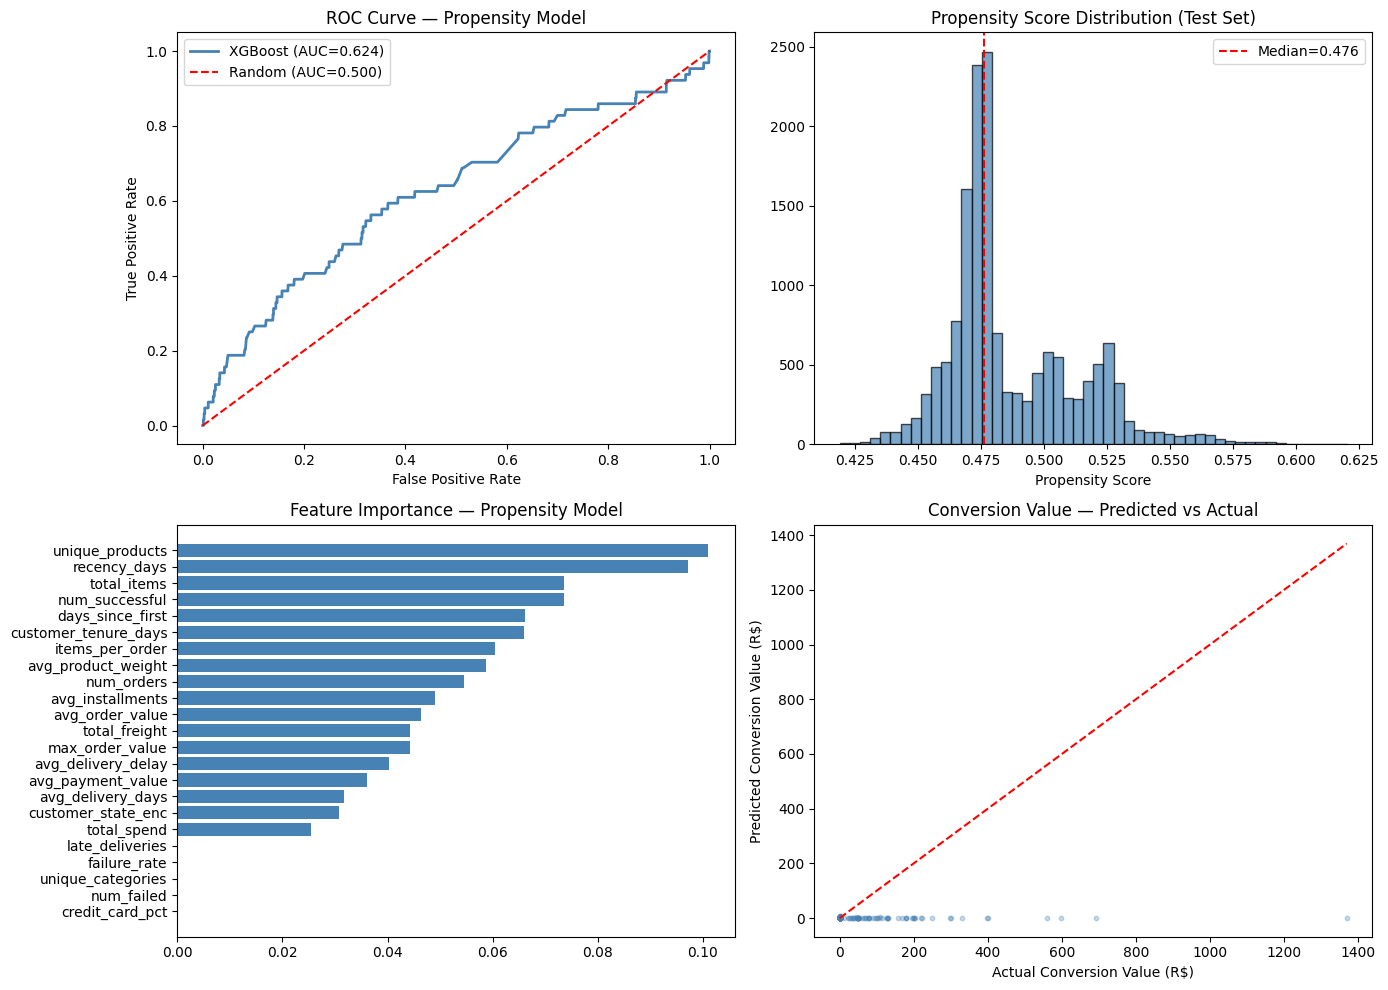

In [34]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

fpr, tpr, _ = roc_curve(y_test_p, test_scores)
auc_val = roc_auc_score(y_test_p, test_scores)
axes[0,0].plot(fpr, tpr, 'steelblue', lw=2, label=f'XGBoost (AUC={auc_val:.3f})')
axes[0,0].plot([0,1], [0,1], 'r--', label='Random (AUC=0.500)')
axes[0,0].set_title('ROC Curve wrt Propensity Model')
axes[0,0].set_xlabel('False Positive Rate')
axes[0,0].set_ylabel('True Positive Rate')
axes[0,0].legend()


axes[0,1].hist(test_scores, bins=50, edgecolor='black', color='steelblue', alpha=0.7)
axes[0,1].axvline(x=np.median(test_scores), color='red', linestyle='--',
                   label=f'Median={np.median(test_scores):.3f}')
axes[0,1].set_title('Propensity Score Distribution')
axes[0,1].set_xlabel('Propensity Score')
axes[0,1].legend()


imp = prop_model.feature_importances_
idx = imp.argsort()
axes[1,0].barh([feature_cols[i] for i in idx], imp[idx], color='steelblue')
axes[1,0].set_title('Feature Importance — Propensity Model')


axes[1,1].scatter(y_test_v, test_preds_v, alpha=0.3, s=10, color='steelblue')
axes[1,1].plot([0, y_test_v.max()], [0, y_test_v.max()], 'r--')
axes[1,1].set_xlabel('Actual Conversion Value')
axes[1,1].set_ylabel('Predicted Conversion Value')
axes[1,1].set_title('Conversion Value')

plt.tight_layout()
plt.show()

---
## 13. Final Output: Score Every Customer

In [35]:
scored = dataset[['customer_unique_id']].copy()
scored['propensity_score'] = prop_model.predict_proba(X)[:, 1]
scored['predicted_conversion_value'] = val_model.predict(X).clip(min=0)

print(scored.describe().round(4))
print('\nTop 15 Ad Targets:')
print(scored.nlargest(15, 'propensity_score').to_string(index=False))

       propensity_score  predicted_conversion_value
count        77808.0000                  77808.0000
mean             0.4866                      0.5342
std              0.0263                      0.1827
min              0.4171                      0.4932
25%              0.4710                      0.4932
50%              0.4763                      0.4973
75%              0.5031                      0.5445
max              0.6271                     10.2434

Top 15 Ad Targets:
              customer_unique_id  propensity_score  predicted_conversion_value
71d790b151c0349e5f5b2fbb4fbe1321          0.627113                    1.942931
76f7d40948174f5cde0fcf8e6147b59d          0.623843                    1.580380
d24e1d0902dac57dd313bcf4f9c80160          0.623528                    2.300729
efce1ab3e96ccab8b1b464326bd22417          0.623117                    3.002203
69768afd389429f6ec48199e5fb8e61a          0.623053                    1.576802
afed5a21e94b4e3e5fbe6c7e4bc92f4c      

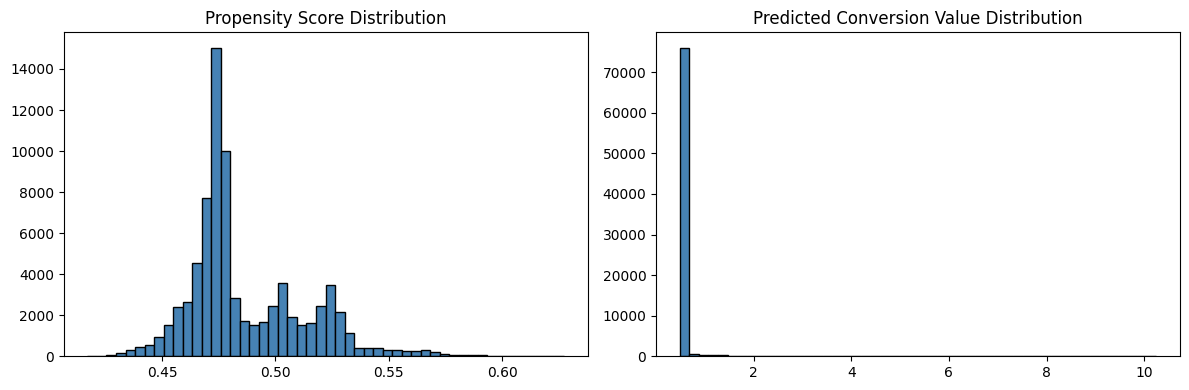

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(scored['propensity_score'], bins=50, edgecolor='black', color='steelblue')
axes[0].set_title('Propensity Score Distribution')

axes[1].hist(scored['predicted_conversion_value'], bins=50, edgecolor='black', color='steelblue')
axes[1].set_title('Predicted Conversion Value Distribution')

plt.tight_layout()
plt.show()